# Earnings Call Prediction — Data Demo

**Author:** Shannon Maccallum  
**Project:** Predicting Stock Returns from Earnings Call Transcripts

This notebook demonstrates the full data loading pipeline:
1. Load earnings call transcripts (Alpha Vantage API, with local caching)
2. Fetch post-earnings stock returns (Yahoo Finance)
3. Combine into a paired dataset
4. Show what the model **inputs** and **targets** look like

---

### Model Inputs and Targets
| Component | Description |
|-----------|-------------|
| **Input** | Earnings call transcript text (tokenized via FinBERT tokenizer) |
| **Target** | Post-earnings return (%) over a configurable window (1, 3, or 5 trading days) |

## 0. Setup

Install the package if you haven't already:
```bash
pip install -e .
```

Add your Alpha Vantage key to a `.env` file in the repo root:
```
ALPHA_VANTAGE_API_KEY=your_key_here
```

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from earnings_transcript_predictor import TranscriptLoader, PriceLoader, EarningsDataset
from earnings_transcript_predictor.utils import clean_transcript

print('Package imported successfully!')

Package imported successfully!


## 1. Load Example Data (no API key needed)

The repo includes 3 pre-fetched example transcripts with their actual post-earnings returns.
This lets the instructor run the notebook without needing an API key.

In [2]:
# Load the bundled example data points
examples_path = Path('../data/examples/example_transcripts.json')
with open(examples_path) as f:
    examples = json.load(f)

print(f'Loaded {len(examples)} example transcripts')
print('\nFields in each record:')
for key in examples[0].keys():
    print(f'  {key}: {type(examples[0][key]).__name__}')

Loaded 3 example transcripts

Fields in each record:
  symbol: str
  quarter: str
  fiscalDateEnding: str
  earnings_date: str
  transcript: str
  return_pct: float
  price_day0: float
  price_dayN: float
  return_window: int
  direction: int


In [3]:
# Quick look at the examples as a DataFrame
df = pd.DataFrame([{
    'symbol': e['symbol'],
    'quarter': e['quarter'],
    'earnings_date': e['earnings_date'],
    'price_day0': e['price_day0'],
    'price_dayN': e['price_dayN'],
    'return_pct': e['return_pct'],
    'direction': e['direction'],
    'return_window': e['return_window'],
    'transcript_words': len(e['transcript'].split()),
} for e in examples])

df

,symbol,quarter,earnings_date,price_day0,price_dayN,return_pct,direction,return_window,transcript_words
0,AAPL,2024Q1,2024-02-01,185.85,184.18,-0.89,0,3,177
1,MSFT,2024Q2,2024-01-30,404.87,415.97,2.74,1,3,122
2,META,2024Q1,2024-04-24,493.50,441.38,-10.56,0,3,139


**Observations:**
- `return_pct` is the **target variable** — what the model will predict
- `direction` is a derived binary label (1 = stock went up, 0 = down)
- Transcripts are ~150–200 words in the examples; real full transcripts are 5,000–15,000 words
- Returns vary a lot: META dropped 10.5% despite strong revenue — driven by capex guidance language

## 2. Fetch a Live Transcript (requires API key)

In [4]:
# Uncomment and run if you have an API key in your .env file
loader = TranscriptLoader()
transcript_data = loader.load('AAPL', '2024Q1')
print(f"Symbol: {transcript_data['symbol']}")
print(f"Quarter: {transcript_data['quarter']}")
print(f"Transcript preview (first 500 chars):")
print(transcript_data['transcript'][:500])

Fetching AAPL 2024Q1 from Alpha Vantage API...
  Cached to data/transcripts/AAPL_2024Q1.json
Symbol: AAPL
Quarter: 2024Q1
Transcript preview (first 500 chars):
[{'speaker': 'Operator', 'title': 'Operator', 'content': "Good day, and welcome to the Apple Q1 Fiscal Year 2024 Earnings Conference Call. Today's call is being recorded. At this time, for opening remarks and introductions. I would like to turn the call over to Suhasini Chandramouli, Director of Investor Relations. Please go ahead.", 'sentiment': '0.0'}, {'speaker': 'Suhasini Chandramouli', 'title': 'Director of Investor Relations', 'content': "Thank you for joining us. Speaking first today is Apple's CEO, Tim Cook; and he'll be followed by CFO, Luca Maestri. After that, we'll open the call to questions from analysts. Before turning the call over to Tim, I would like to remind everyone that the quarter we're reporting today included 13 weeks, whereas the quarter we reported a year ago included 14 weeks. Please note that some of 

**Caching note:** After the first API call, the transcript is saved to `data/transcripts/AAPL_2024Q1.json`. Every subsequent call reads from disk — no API hit. This addresses the instructor's feedback about not re-hitting the API on every batch run.

## 3. Compute Post-Earnings Returns

In [5]:
# Demonstrate the PriceLoader with a real ticker (uses Yahoo Finance, no API key needed)
price_loader = PriceLoader(return_window=3)

result = price_loader.get_return('AAPL', '2024-02-01')
print('Return data for AAPL Q1 2024 earnings:')
for k, v in result.items():
    print(f'  {k}: {v}')

Return data for AAPL Q1 2024 earnings:
  symbol: AAPL
  earnings_date: 2024-02-01
  return_window: 3
  price_day0: 184.7685
  price_dayN: 187.1812
  return_pct: 1.3058
  direction: 1


In [6]:
# Batch returns for all example tickers
pairs = [(e['symbol'], e['earnings_date']) for e in examples]
returns_df = price_loader.get_returns_batch(pairs)
print('Batch returns:')
returns_df

Batch returns:


,symbol,earnings_date,return_window,price_day0,price_dayN,return_pct,direction
0,AAPL,2024-02-01,3,184.7685,187.1812,1.3058,1
1,MSFT,2024-01-30,3,400.8026,403.3824,0.6437,1
2,META,2024-04-24,3,490.1770,429.7068,-12.3364,0


### Return Window Discussion

Per the instructor's feedback, the return window matters a lot:

| Window | What it captures | Consideration |
|--------|-----------------|---------------|
| **1 day** | Immediate market reaction | If call is after-hours, day 0 close already moves; this captures *next-day* drift |
| **3 days** | Short-term drift post-announcement | Most common in event studies; balances signal vs. noise |
| **5 days** | One full trading week | More noise from unrelated market events |

We default to **3 days** for now. The `PriceLoader(return_window=N)` makes it easy to experiment.

## 4. Text Preprocessing

In [7]:
from earnings_transcript_predictor.utils import clean_transcript

raw = examples[0]['transcript']
cleaned = clean_transcript(raw)

print(f'Raw length:    {len(raw)} chars')
print(f'Cleaned length: {len(cleaned)} chars')
print(f'\nCleaned preview:')
print(cleaned[:400])

Raw length:    1062 chars
Cleaned length: 1062 chars

Cleaned preview:
Good afternoon, everyone. Thank you for joining Apple's first quarter fiscal 2024 earnings conference call. I'm Suhasini Chandramouli, Director of Investor Relations, and with me today is Tim Cook, Apple's CEO, and Luca Maestri, Apple's CFO. We are providing a presentation today that is available on our website with more detail than usual. As a reminder, a replay of today's call will be available 


## 5. PyTorch Dataset — Model Inputs & Targets

In [8]:
# Build the dataset from our example records
# In real training, 'examples' would be thousands of transcript+return dicts

dataset = EarningsDataset(examples, max_length=128)  # 128 for demo speed; use 512 for training
print(f'Dataset size: {len(dataset)} samples')

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Dataset size: 3 samples


In [9]:
# Inspect a single sample — this is exactly what the model will receive
sample = dataset[0]

print('=== MODEL INPUTS ===')
print(f'input_ids shape:      {sample["input_ids"].shape}   (one token ID per position)')
print(f'attention_mask shape: {sample["attention_mask"].shape}   (1=real token, 0=padding)')
print(f'\ninput_ids (first 20 tokens): {sample["input_ids"][:20]}')

print('\n=== MODEL TARGET ===')
print(f'return_pct (label):   {sample["label"]:.4f}%')

print('\n=== METADATA ===')
print(f'symbol:               {sample["symbol"]}')
print(f'quarter:              {sample["quarter"]}')
print(f'earnings_date:        {sample["earnings_date"]}')

=== MODEL INPUTS ===
input_ids shape:      torch.Size([128])   (one token ID per position)
attention_mask shape: torch.Size([128])   (1=real token, 0=padding)

input_ids (first 20 tokens): tensor([  101,  2204,  5027,  1010,  3071,  1012,  4067,  2017,  2005,  5241,
         6207,  1005,  1055,  2034,  4284, 10807, 16798,  2549, 16565,  3034])

=== MODEL TARGET ===
return_pct (label):   -0.8900%

=== METADATA ===
symbol:               AAPL
quarter:              2024Q1
earnings_date:        2024-02-01


**Summary of model I/O:**
- **Input:** `input_ids` tensor of shape `(512,)` — the tokenized transcript
- **Input:** `attention_mask` tensor of shape `(512,)` — tells the model which tokens are real vs. padding
- **Target:** `label` scalar — the post-earnings return % (e.g. `2.74` or `-10.56`)

## 6. Target Variable Distribution

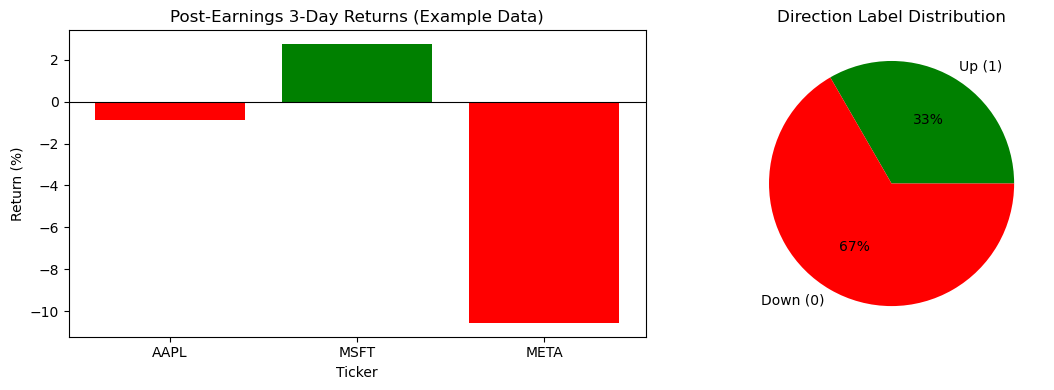

Mean return: -2.90%
Std return:  6.87%

Note: With a full dataset (100s of transcripts), we expect high variance
and roughly equal up/down split, consistent with the efficient market hypothesis.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Return distribution
returns = [e['return_pct'] for e in examples]
axes[0].bar([e['symbol'] for e in examples], returns, color=['red' if r < 0 else 'green' for r in returns])
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('Post-Earnings 3-Day Returns (Example Data)')
axes[0].set_ylabel('Return (%)')
axes[0].set_xlabel('Ticker')

# Direction breakdown
directions = [e['direction'] for e in examples]
axes[1].pie(
    [sum(directions), len(directions) - sum(directions)],
    labels=['Up (1)', 'Down (0)'],
    colors=['green', 'red'],
    autopct='%1.0f%%',
)
axes[1].set_title('Direction Label Distribution')

plt.tight_layout()
plt.show()

print(f'Mean return: {pd.Series(returns).mean():.2f}%')
print(f'Std return:  {pd.Series(returns).std():.2f}%')
print('\nNote: With a full dataset (100s of transcripts), we expect high variance')
print('and roughly equal up/down split, consistent with the efficient market hypothesis.')

## Summary

This notebook demonstrated:
1. ✅ **TranscriptLoader** — fetches and caches Alpha Vantage transcripts
2. ✅ **PriceLoader** — computes configurable-window post-earnings returns from Yahoo Finance
3. ✅ **EarningsDataset** — PyTorch Dataset pairing tokenized transcripts with return targets
4. ✅ **Model inputs:** `input_ids` and `attention_mask` tensors of shape `(512,)`
5. ✅ **Model target:** `return_pct` float (percentage return over N trading days)

Next milestones will cover: full data collection, FinBERT fine-tuning, and evaluation.